# Project Title: House Price Prediction

## Step 1: Setup and Data Loading

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
sns.set_style('whitegrid')

In [21]:
# Load the dataset
df = pd.read_csv('Kc_House_Data.csv')
print("First 5 rows of data:")
print(df.head())
print("\nData Info:")
print(df.info())
print("\nDataset Shape:", df.shape)
print("\nSummary statistics:")
print(df.describe())

First 5 rows of data:
           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0       3.0       1.00         1180   
1  6414100192  20141209T000000  538000.0       3.0       2.25         2570   
2  5631500400  20150225T000000  180000.0       2.0       1.00          770   
3  2487200875  20141209T000000  604000.0       4.0       3.00         1960   
4  1954400510  20150218T000000  510000.0       3.0       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_renovated  z

## Step 2: Exploratory Data Analysis (EDA)

### 1. Correlation Analysis & Heatmap

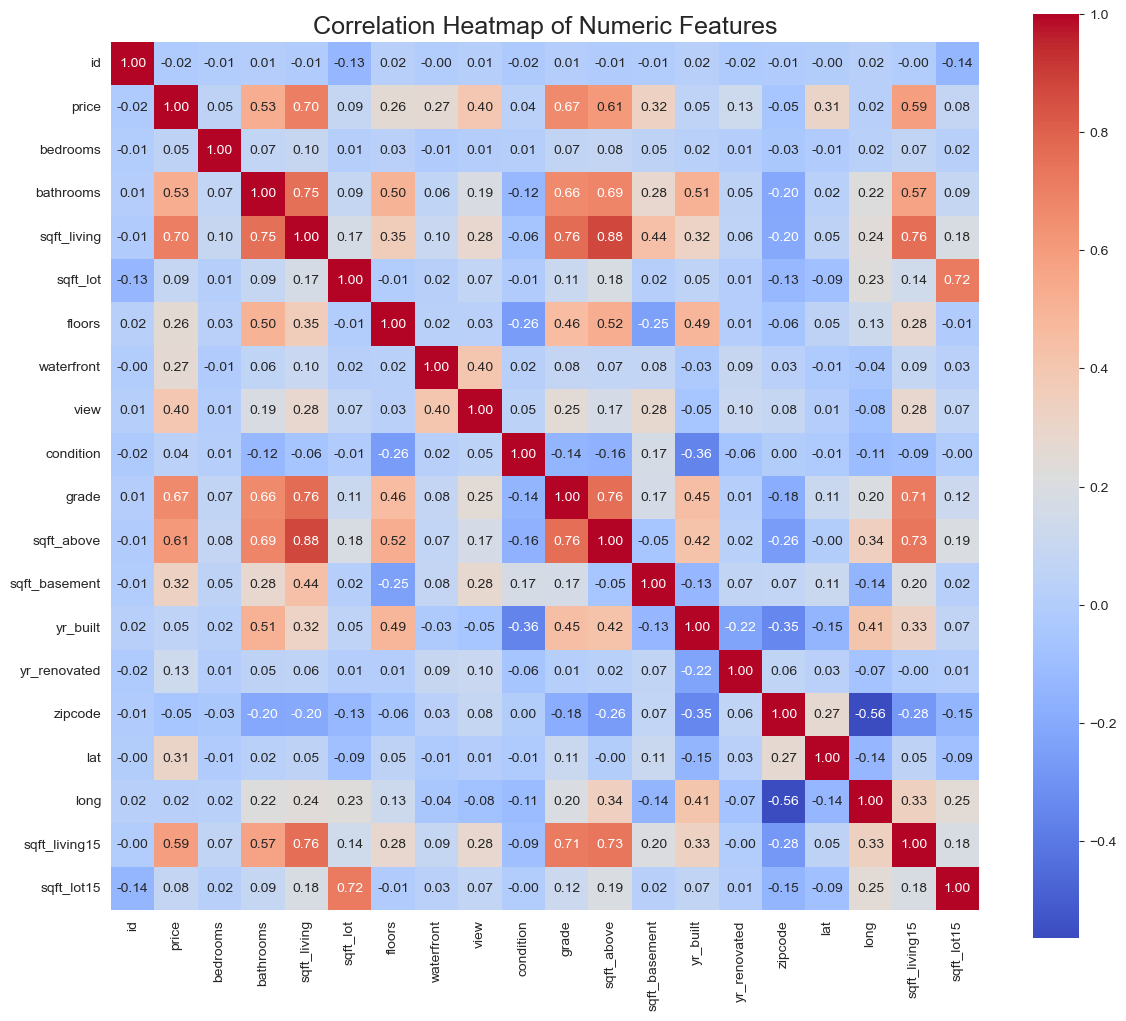

In [4]:
# Select numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 12))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Heatmap of Numeric Features", fontsize=18)
plt.show()

### 2. Histograms for distribution

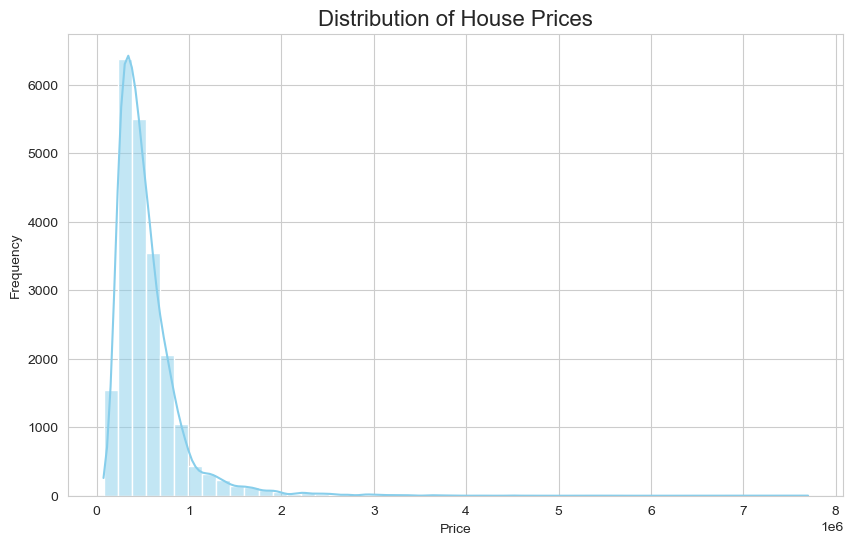

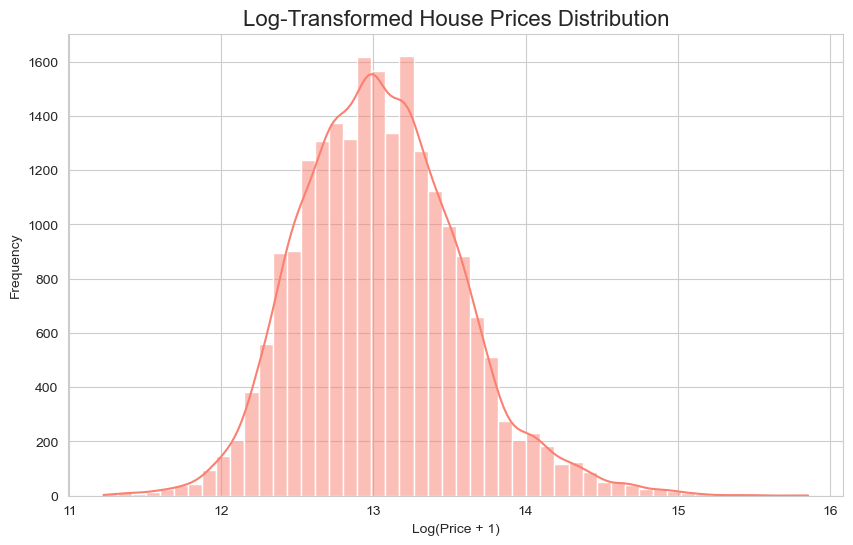

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True, color='skyblue')
plt.title("Distribution of House Prices", fontsize=16)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()
# Log-transform price to reduce skew
plt.figure(figsize=(10,6))
sns.histplot(np.log1p(df['price']), bins=50, kde=True, color='salmon')
plt.title("Log-Transformed House Prices Distribution", fontsize=16)
plt.xlabel("Log(Price + 1)")
plt.ylabel("Frequency")
plt.show()

### 3. Boxplot to check for outliers (e.g., Bedrooms)

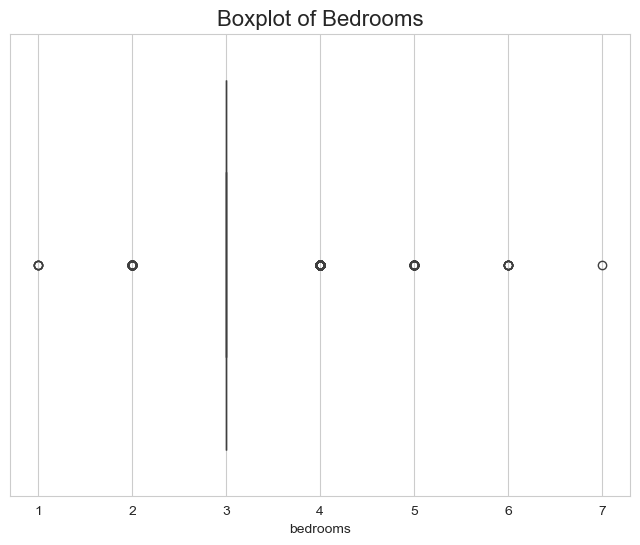

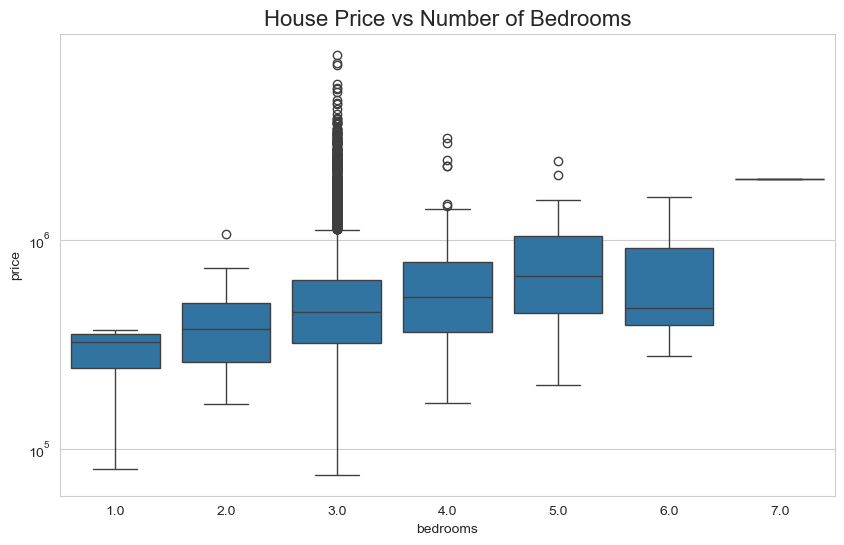

In [6]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['bedrooms'])
plt.title("Boxplot of Bedrooms", fontsize=16)
plt.show()
plt.figure(figsize=(10,6))
sns.boxplot(x='bedrooms', y='price', data=df)
plt.title("House Price vs Number of Bedrooms", fontsize=16)
plt.yscale('log')  # better visualization for skewed prices
plt.show()

## Step 3: Handling Data Challenges

### 1. Check for missing values

In [7]:
print("Missing values per column:")
print(df.isnull().sum())
# Drop missing values (for simplicity)
df_clean = df.dropna()
print("\nShape after dropping missing values:", df_clean.shape)

Missing values per column:
id                0
date              0
price             0
bedrooms         12
bathrooms         0
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
grade             0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
zipcode           0
lat               0
long              0
sqft_living15     0
sqft_lot15        0
dtype: int64

Shape after dropping missing values: (21601, 21)


### 2. Handling Outliers (Irregularities)

In [8]:
print(f"Original shape: {df_clean.shape}")
# Remove unrealistic bedroom counts
# Remove duplicate house listings
df_clean = df.drop_duplicates(subset=['id'], keep='first')

# Basic cleaning example (if needed)
df_clean = df_clean[df_clean['bedrooms'] <= 8]   # remove unrealistic houses
df_clean = df_clean.reset_index(drop=True)
df_clean = df_clean[(df_clean['bedrooms'] >= 1) & (df_clean['bedrooms'] <= 8)]
# Remove unrealistic bathroom counts
df_clean = df_clean[(df_clean['bathrooms'] >= 1) & (df_clean['bathrooms'] <= 6)]
# Remove extreme sqft_living homes (luxury outliers)
df_clean = df_clean[(df_clean['sqft_living'] >= 300) & (df_clean['sqft_living'] <= 6000)]
# Remove extreme lot sizes
df_clean = df_clean[(df_clean['sqft_lot'] <= 50000)]
# Remove extremely high priced homes (luxury market outliers)
df_clean = df_clean[(df_clean['price'] <= 2500000)]
# Remove grade outliers
df_clean = df_clean[(df_clean['grade'] >= 5) & (df_clean['grade'] <= 12)]
print(f"Shape after removing outliers: {df_clean.shape}")

Original shape: (21601, 21)
Shape after removing outliers: (20339, 21)


In [9]:
# Remove duplicate house listings
df_clean = df.drop_duplicates(subset=['id'], keep='first')

# Remove unrealistic bedrooms
df_clean = df_clean[df_clean['bedrooms'] <= 8]

# Optional: remove other outliers (price, bathrooms, sqft_living, etc.)
df_clean = df_clean[df_clean['bathrooms'] <= 6]
df_clean = df_clean[df_clean['sqft_living'] <= 6000]
df_clean = df_clean[df_clean['sqft_lot'] <= 50000]
df_clean = df_clean[df_clean['price'] <= 2500000]

df_clean = df_clean.reset_index(drop=True)


### 3. Drop irrelevant columns

In [10]:
# Drop 'id' and 'date', keep numeric features
df_model = df_clean.drop(['id', 'date'], axis=1)
# Add log-transformed target
df_model['price_log'] = np.log1p(df_model['price'])

## Step 4: Model Design & Evaluation

In [25]:
# Features and target
X = df_model.drop(['price', 'price_log'], axis=1)
y = df_model['price_log']  # use log-transformed price
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Initialize and train model
model = LinearRegression()
model.fit(X_train_scaled, y_train)
# Predictions
y_pred = model.predict(X_test_scaled)
# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("Model Evaluation (Log-Price):")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"MAE  : {mae:,.2f}")
print(f"R2 Score: {r2:.4f}")

#Using Polynomial

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

model = LinearRegression()
model.fit(X_train_poly, y_train)
y_pred = model.predict(X_test_poly)

print("R2 Score using polynomial: ",r2_score(y_test, y_pred))

Model Evaluation (Log-Price):
MSE  : 0.06
RMSE : 0.25
MAE  : 0.19
R2 Score: 0.7662
R2 Score using polynomial:  0.8219142493398377


## Optional: Using LightGBM model for higher accuracy

In [26]:
lgbm = LGBMRegressor(
    n_estimators=1500,       # more trees = higher accuracy
    learning_rate=0.03,      # small LR improves precision
    num_leaves=50,           # controls model complexity
    max_depth=-1,            # no depth limit
    subsample=0.8,           # row sampling for generalization
    colsample_bytree=0.8,    # feature sampling
    reg_alpha=1.0,           # L1 regularization
    reg_lambda=2.0,          # L2 regularization
    min_child_samples=20,
    random_state=42
)

# Fit model
lgbm.fit(X_train, y_train)

# Predict
y_pred = lgbm.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
mae = mean_absolute_error(y_test, y_pred)

print("LightGBM Model Performance:")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"MAE  : {mae:,.2f}")
print(f"R2 Score: {r2:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001579 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2313
[LightGBM] [Info] Number of data points in the train set: 16347, number of used features: 18
[LightGBM] [Info] Start training from score 13.028819
LightGBM Model Performance:
MSE  : 0.03
RMSE : 0.16
MAE  : 0.11
R2 Score: 0.9051


## Step 5: Insights & Recommendations

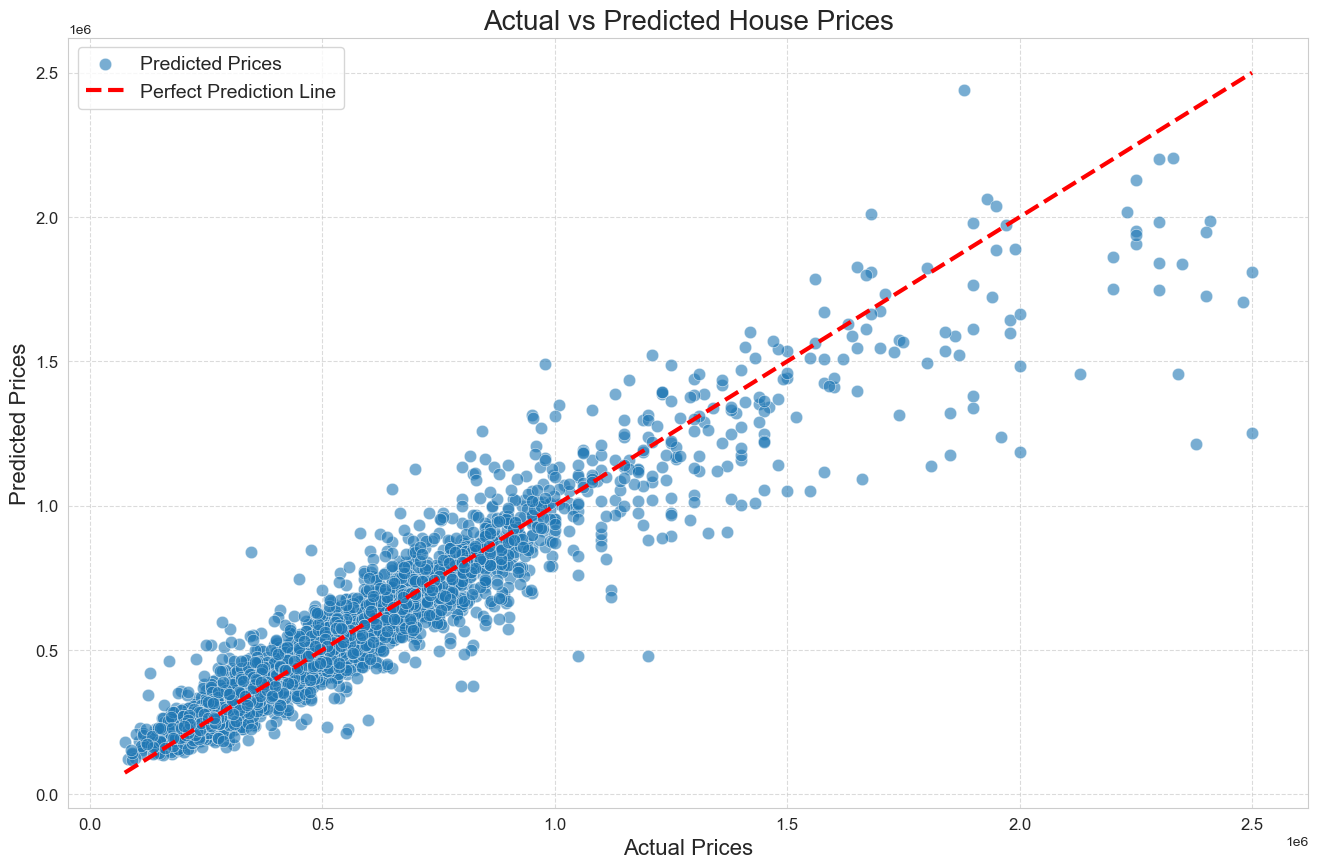

In [27]:
# Convert predictions back to original scale
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred)

plt.figure(figsize=(16, 10))
plt.scatter(y_test_orig, y_pred_orig, alpha=0.6, s=80, color='#1f77b4', edgecolor='white', linewidth=0.5, label='Predicted Prices')
min_val = min(y_test_orig.min(), y_pred_orig.min())
max_val = max(y_test_orig.max(), y_pred_orig.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=3, label='Perfect Prediction Line')
plt.xlabel("Actual Prices", fontsize=16)
plt.ylabel("Predicted Prices", fontsize=16)
plt.title("Actual vs Predicted House Prices", fontsize=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=14)
plt.show()